In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst Look:")
df.head()

Shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Data Types:
 Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

First Look:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


=== BASIC INFO ===
Total Reviews: 568,454

Missing Values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score Distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


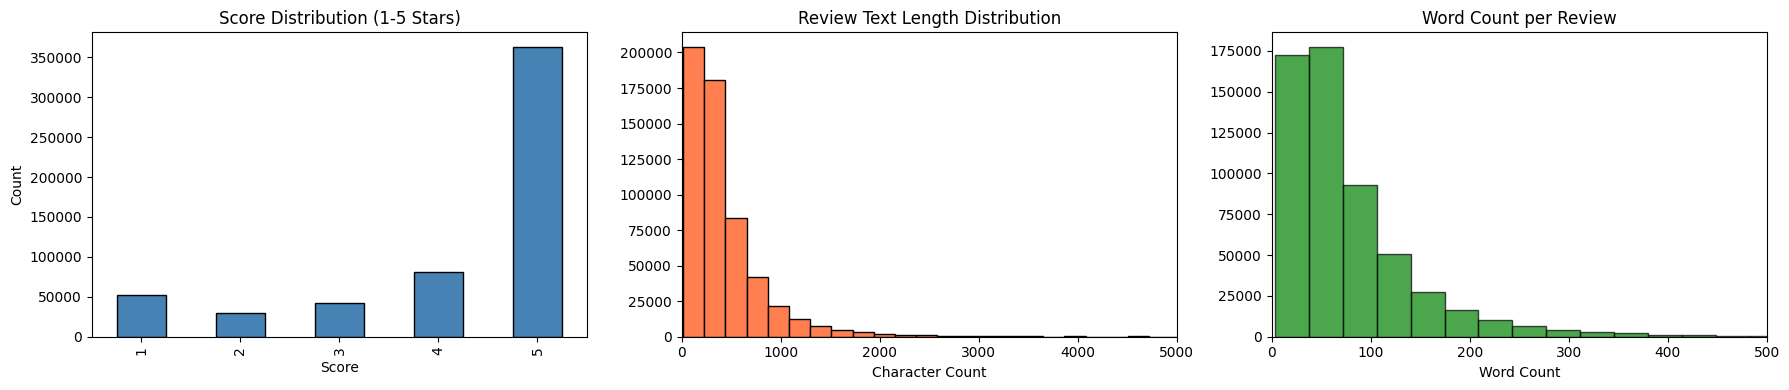


=== AVG WORD COUNT BY SCORE ===
Score
1    87.3
2    90.0
3    95.6
4    91.4
5    74.2
Name: word_count, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Basic Stats ---
print("=== BASIC INFO ===")
print(f"Total Reviews: {len(df):,}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nScore Distribution:\n{df['Score'].value_counts().sort_index()}")

# --- Score Distribution Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Score counts
df['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
                                              color='steelblue', edgecolor='black')
axes[0].set_title('Score Distribution (1-5 Stars)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Plot 2: Review Text Length distribution
df['text_length'] = df['Text'].astype(str).apply(len)
axes[1].hist(df['text_length'], bins=100, color='coral', edgecolor='black')
axes[1].set_title('Review Text Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].set_xlim(0, 5000)

# Plot 3: Word count per review
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))
axes[2].hist(df['word_count'], bins=100, color='green', edgecolor='black', alpha=0.7)
axes[2].set_title('Word Count per Review')
axes[2].set_xlabel('Word Count')
axes[2].set_xlim(0, 500)

plt.tight_layout()
plt.show()

# --- Text length stats by score ---
print("\n=== AVG WORD COUNT BY SCORE ===")
print(df.groupby('Score')['word_count'].mean().round(1))

##  Step 3: Text Preprocessing

Raw text is messy — HTML tags, punctuation, numbers, stopwords all add noise.
We'll build a reusable cleaning pipeline covering:
- Lowercasing
- Removing HTML tags (this is Amazon — lots of <br> tags!)
- Removing punctuation & special characters
- Removing numbers
- Stopword removal
- Stemming vs Lemmatization (we'll try both)

In [4]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# ---- Cleaning Functions ----

def remove_html(text):
    """Remove HTML tags like <br />, <b>, etc."""
    return re.sub(r'<.*?>', ' ', text)

def remove_special_chars(text):
    """Keep only alphabets and spaces"""
    return re.sub(r'[^a-zA-Z\s]', '', text)

def remove_stopwords(text):
    """Remove common stopwords"""
    return ' '.join([w for w in text.split() if w not in stop_words])

def stem_text(text):
    """Stemming - chops word to root (running -> run)"""
    return ' '.join([stemmer.stem(w) for w in text.split()])

def lemmatize_text(text):
    """Lemmatization - proper root form (better than stemming)"""
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()])

def full_clean(text):
    text = str(text).lower()         # lowercase
    text = remove_html(text)          # remove HTML
    text = remove_special_chars(text) # remove punctuation/numbers
    text = remove_stopwords(text)     # remove stopwords
    text = lemmatize_text(text)       # lemmatize
    text = text.strip()
    return text

# ---- Show Before vs After on 3 examples ----
print("=== BEFORE vs AFTER CLEANING ===\n")
for i in [0, 100, 500]:
    print(f"--- Review #{i} ---")
    print(f"BEFORE: {df['Text'].iloc[i][:200]}")
    print(f"AFTER : {full_clean(df['Text'].iloc[i])[:200]}")
    print()

# ---- Apply to full dataset (takes ~1-2 min) ----
print("Cleaning all reviews... please wait ⏳")
df['cleaned_text'] = df['Text'].apply(full_clean)
print("✅ Done! Sample cleaned reviews:")
df[['Text', 'cleaned_text', 'Score']].head(3)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


=== BEFORE vs AFTER CLEANING ===

--- Review #0 ---
BEFORE: I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador
AFTER : bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better

--- Review #100 ---
BEFORE: The mouth says, "How do I love thee, let me count the ways..."<br />If you like apple products a must have item.  The only draw back, shipping cost.  These are very heavy.
AFTER : mouth say love thee let count way like apple product must item draw back shipping cost heavy

--- Review #500 ---
BEFORE: I bought these for the office and no one can put them down. I'm ordering more today and it has only been 2 weeks. Didn't have to shop for them either, Amazon brought it to my door!
AFTER : bought office one put im ordering today week didn

,Text,cleaned_text,Score
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,5
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,1
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...,4


##  Step 4: EDA on Cleaned Text — WordClouds & Top Words

Now that text is clean, let's visually explore:
- What words dominate positive (5-star) vs negative (1-star) reviews?
- Top 20 most frequent words per sentiment
- This helps us understand what features matter before modeling

Positive reviews (5★): 363,122
Negative reviews (1★): 52,268


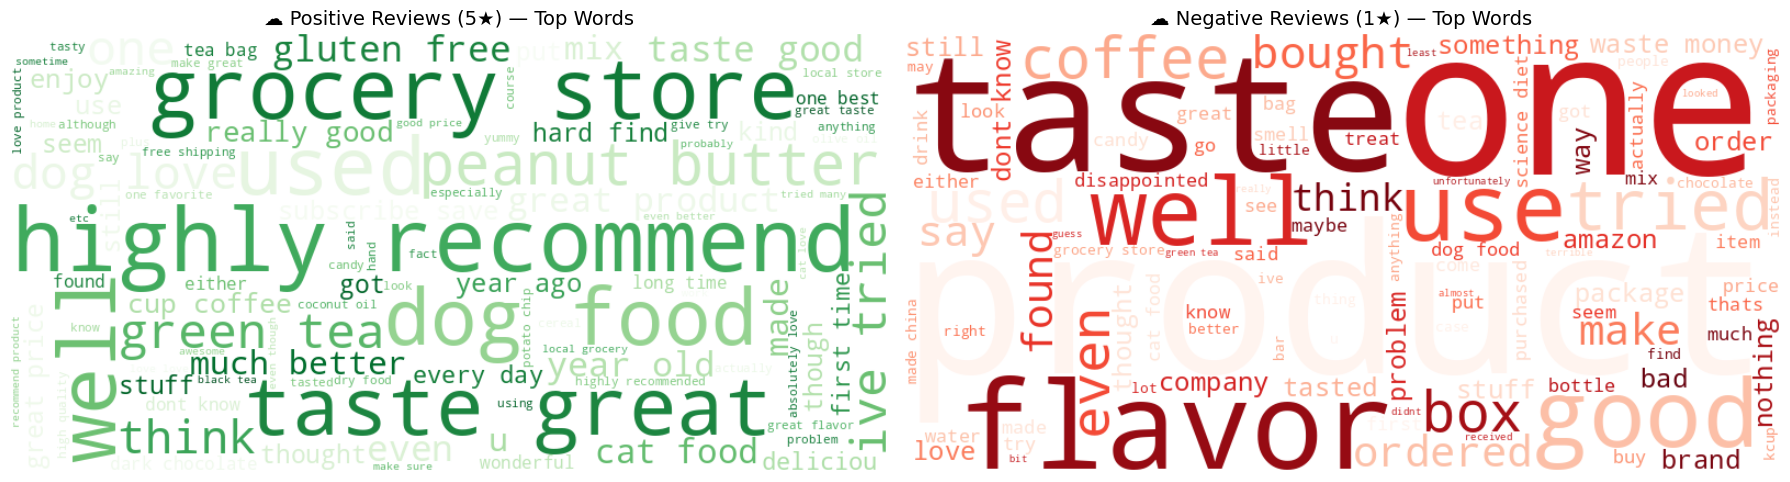

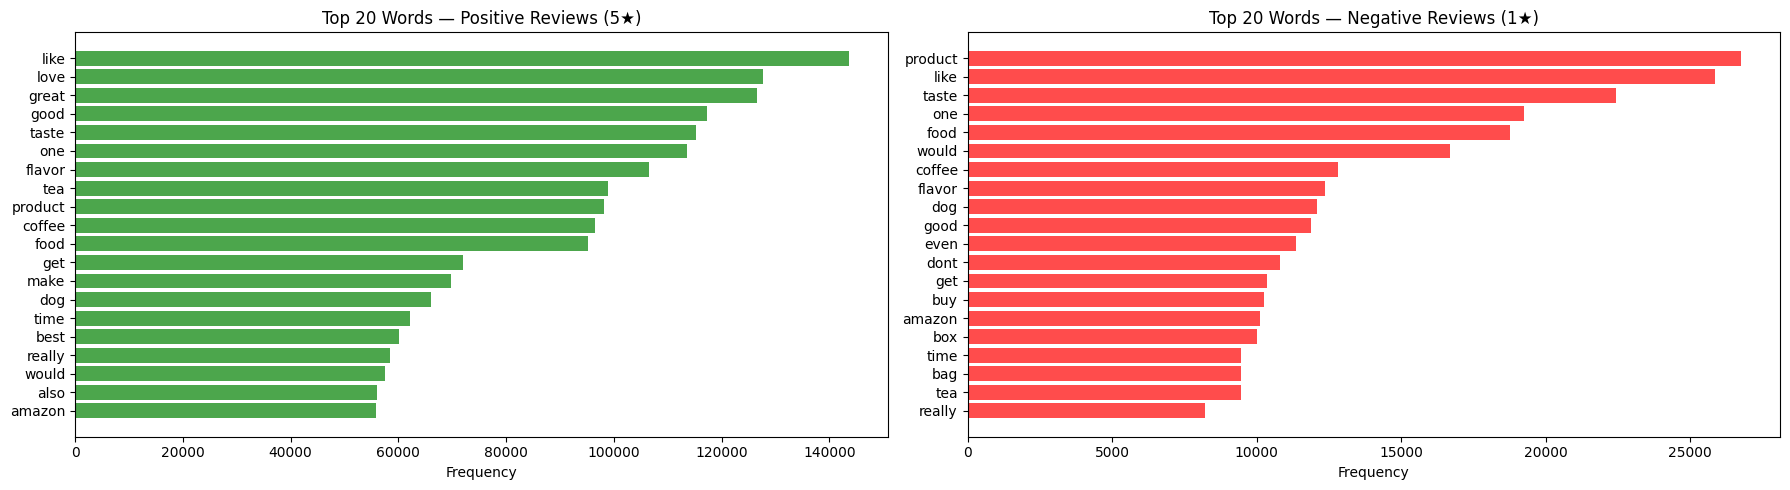


Words dominant in POSITIVE reviews: {'fresh', 'definitely', 'size', 'home', 'friend', 'enough', 'wonderful', 'family', 'delicious', 'perfect', 'tasting', 'keep', 'butter', 'bit', 'easy', 'favorite', 'loved', 'strong', 'excellent', 'protein', 'highly', 'nice', 'texture', 'quite', 'morning', 'big', 'peanut', 'theyre', 'add', 'calorie', 'regular', 'fruit', 'snack', 'enjoy', 'rice', 'variety', 'per', 'help', 'low', 'fat', 'coconut', 'grocery', 'healthy', 'tasty', 'cooky', 'without', 'kid', 'sauce', 'far', 'happy', 'blend'}

 Words dominant in NEGATIVE reviews: {'thought', 'disappointed', 'half', 'received', 'either', 'worst', 'read', 'can', 'least', 'date', 'may', 'case', 'company', 'tasted', 'ill', 'awful', 'away', 'please', 'china', 'bad', 'thats', 'piece', 'instead', 'wanted', 'went', 'purchased', 'said', 'three', 'took', 'nothing', 'maybe', 'money', 'horrible', 'customer', 'pet', 'opened', 'corn', 'gave', 'couldnt', 'return', 'however', 'cost', 'came', 'label', 'formula', 'item', 'won

In [5]:
from wordcloud import WordCloud
from collections import Counter

# ---- Create Sentiment buckets ----
positive = df[df['Score'] == 5]['cleaned_text'].astype(str)
negative = df[df['Score'] == 1]['cleaned_text'].astype(str)

print(f"Positive reviews (5★): {len(positive):,}")
print(f"Negative reviews (1★): {len(negative):,}")

# ---- WordClouds ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_pos = WordCloud(width=800, height=400, 
                   background_color='white',
                   colormap='Greens',
                   max_words=100).generate(' '.join(positive))

wc_neg = WordCloud(width=800, height=400,
                   background_color='white', 
                   colormap='Reds',
                   max_words=100).generate(' '.join(negative))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('☁️ Positive Reviews (5★) — Top Words', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('☁️ Negative Reviews (1★) — Top Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ---- Top 20 words bar chart ----
def get_top_words(series, n=20):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

pos_words = get_top_words(positive)
neg_words = get_top_words(negative)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Positive
words, counts = zip(*pos_words)
axes[0].barh(words[::-1], counts[::-1], color='green', alpha=0.7)
axes[0].set_title('Top 20 Words — Positive Reviews (5★)')
axes[0].set_xlabel('Frequency')

# Negative
words, counts = zip(*neg_words)
axes[1].barh(words[::-1], counts[::-1], color='red', alpha=0.7)
axes[1].set_title('Top 20 Words — Negative Reviews (1★)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

# ---- Words unique to positive but not in negative top 200 ----
pos_set = set([w for w,_ in get_top_words(positive, 200)])
neg_set = set([w for w,_ in get_top_words(negative, 200)])

print("\nWords dominant in POSITIVE reviews:", pos_set - neg_set)
print("\n Words dominant in NEGATIVE reviews:", neg_set - pos_set)

## Step 5: Feature Engineering — Bag of Words & TF-IDF

Before feeding text into ML models, we must convert words into numbers.
Two classical approaches:

1. **Bag of Words (BOW)** — counts word frequency, ignores order
2. **TF-IDF** — rewards rare important words, penalizes common ones
   - TF  = how often word appears in THIS document
   - IDF = how rare the word is across ALL documents
   - TF-IDF = TF × IDF

We'll also create a binary sentiment column:
- Score 4,5 → Positive (1)
- Score 1,2 → Negative (0)
- Score 3 → dropped (neutral/ambiguous)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# ---- Create Binary Sentiment ----
# Drop neutral (score=3), map 1,2 → 0 (negative), 4,5 → 1 (positive)
df_model = df[df['Score'] != 3].copy()
df_model['sentiment'] = df_model['Score'].apply(lambda x: 1 if x >= 4 else 0)

print("=== SENTIMENT DISTRIBUTION ===")
print(df_model['sentiment'].value_counts())
print(f"\nTotal samples for modeling: {len(df_model):,}")

# ---- Handle Imbalance by undersampling ----
pos = df_model[df_model['sentiment'] == 1]
neg = df_model[df_model['sentiment'] == 0]

# Undersample positive to match negative count
pos_sampled = pos.sample(n=len(neg), random_state=42)
df_balanced = pd.concat([pos_sampled, neg]).sample(frac=1, random_state=42)

print(f"\n=== AFTER BALANCING ===")
print(df_balanced['sentiment'].value_counts())
print(f"Total balanced samples: {len(df_balanced):,}")

# ---- Train Test Split ----
X = df_balanced['cleaned_text']
y = df_balanced['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train):,}")
print(f"Test size : {len(X_test):,}")

# ---- BOW Vectorizer ----
print("\n Fitting BOW vectorizer...")
bow_vectorizer = CountVectorizer(max_features=10000, min_df=5)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)
print(f"BOW Matrix shape: {X_train_bow.shape}")

# ---- TF-IDF Vectorizer ----
print("\n Fitting TF-IDF vectorizer...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000, min_df=5, 
                                    ngram_range=(1,2))  # unigrams + bigrams!
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f"TF-IDF Matrix shape: {X_train_tfidf.shape}")

# ---- Show top TF-IDF terms ----
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n Sample TF-IDF features (first 20): {list(feature_names[:20])}")
print(f"Sample TF-IDF features (last 20) : {list(feature_names[-20:])}")

=== SENTIMENT DISTRIBUTION ===
sentiment
1    443777
0     82037
Name: count, dtype: int64

Total samples for modeling: 525,814

=== AFTER BALANCING ===
sentiment
1    82037
0    82037
Name: count, dtype: int64
Total balanced samples: 164,074

Train size: 131,259
Test size : 32,815

 Fitting BOW vectorizer...
BOW Matrix shape: (131259, 10000)

 Fitting TF-IDF vectorizer...
TF-IDF Matrix shape: (131259, 10000)

 Sample TF-IDF features (first 20): ['ability', 'able', 'able buy', 'able eat', 'able find', 'able get', 'able make', 'able order', 'able purchase', 'able use', 'absolute', 'absolute favorite', 'absolutely', 'absolutely awful', 'absolutely best', 'absolutely delicious', 'absolutely horrible', 'absolutely love', 'absolutely loved', 'absolutely nothing']
Sample TF-IDF features (last 20) : ['yr old', 'yuck', 'yucky', 'yuk', 'yum', 'yummy', 'zealand', 'zero', 'zero calorie', 'zero star', 'zevia', 'zico', 'zinc', 'zing', 'zip', 'zip lock', 'ziploc', 'ziplock', 'ziplock bag', 'zukes']


##  Step 6: ML Models — Naive Bayes & Logistic Regression

We'll train 4 models and compare:
| Model                        | Vectorizer |
|------------------------------|------------|
| Multinomial Naive Bayes      | BOW        |
| Multinomial Naive Bayes      | TF-IDF     |
| Logistic Regression          | BOW        |
| Logistic Regression          | TF-IDF     |

**Why these models first?**
- Naive Bayes: fastest, works surprisingly well on text, great baseline
- Logistic Regression: stronger, learns word weights, very interpretable

Metrics: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

⏳ Training models...


 Naive Bayes + BOW
Accuracy: 0.8581
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85     16408
    Positive       0.84      0.89      0.86     16407

    accuracy                           0.86     32815
   macro avg       0.86      0.86      0.86     32815
weighted avg       0.86      0.86      0.86     32815


 Naive Bayes + TF-IDF
Accuracy: 0.8799
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88     16408
    Positive       0.87      0.89      0.88     16407

    accuracy                           0.88     32815
   macro avg       0.88      0.88      0.88     32815
weighted avg       0.88      0.88      0.88     32815


 Logistic Regression + BOW
Accuracy: 0.8954
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90     16408
    Positive       0.89      0.90      0.90     16407

    accuracy                          

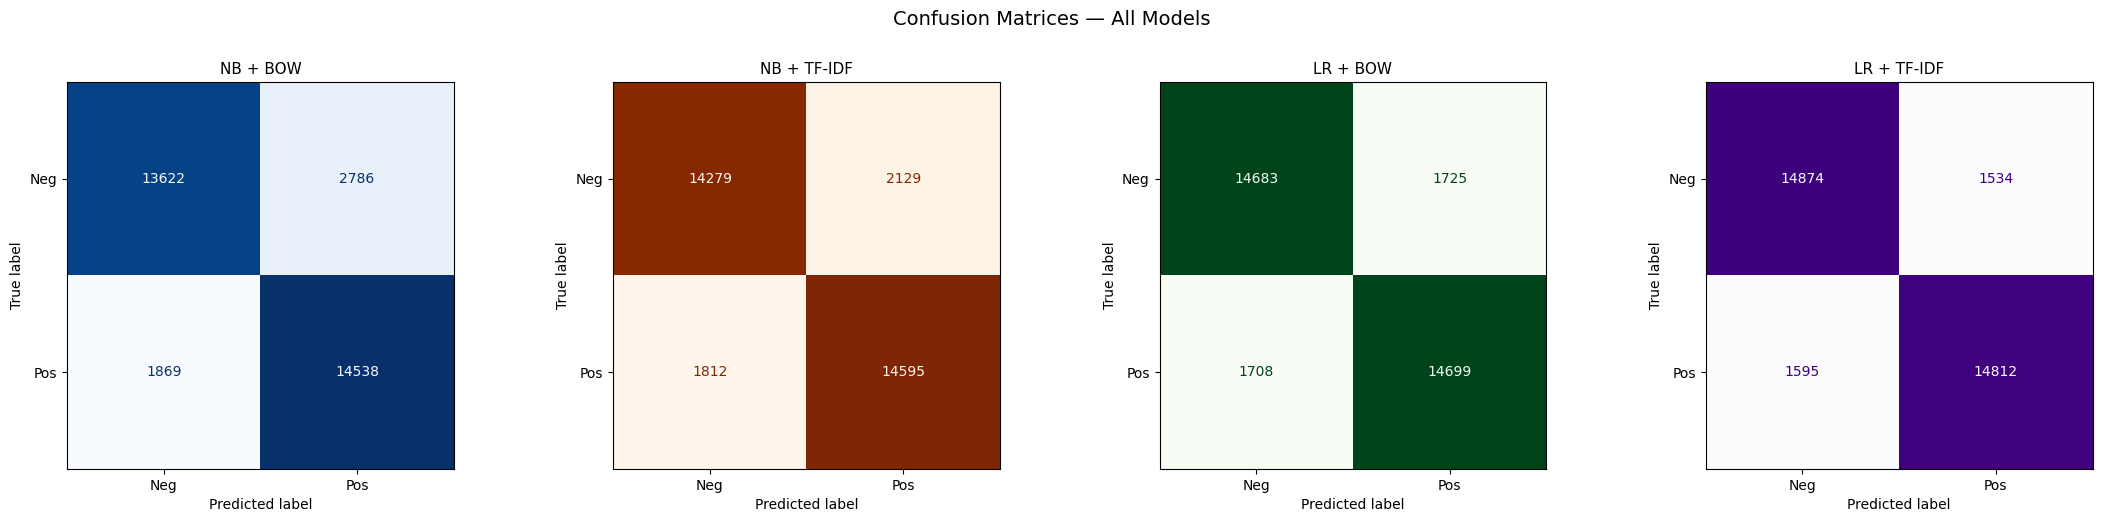


===  MODEL COMPARISON SUMMARY ===
                       Model  Accuracy
Logistic Regression + TF-IDF  0.904647
   Logistic Regression + BOW  0.895383
        Naive Bayes + TF-IDF  0.879902
           Naive Bayes + BOW  0.858144


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, ConfusionMatrixDisplay)

results = {}

def train_evaluate(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    results[name] = {
        'accuracy': acc,
        'preds': preds,
        'model': model
    }
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_te, preds, 
          target_names=['Negative', 'Positive']))
    return preds

# ---- Train all 4 models ----
print("⏳ Training models...\n")

p1 = train_evaluate(MultinomialNB(), 
                    X_train_bow, X_test_bow, y_train, y_test,
                    "Naive Bayes + BOW")

p2 = train_evaluate(MultinomialNB(), 
                    X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "Naive Bayes + TF-IDF")

p3 = train_evaluate(LogisticRegression(max_iter=1000, C=1.0), 
                    X_train_bow, X_test_bow, y_train, y_test,
                    "Logistic Regression + BOW")

p4 = train_evaluate(LogisticRegression(max_iter=1000, C=1.0), 
                    X_train_tfidf, X_test_tfidf, y_train, y_test,
                    "Logistic Regression + TF-IDF")

# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
names  = ["NB + BOW", "NB + TF-IDF", "LR + BOW", "LR + TF-IDF"]
preds  = [p1, p2, p3, p4]
colors = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, name, pred, cmap in zip(axes, names, preds, colors):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Neg', 'Pos'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary Table ----
print("\n===  MODEL COMPARISON SUMMARY ===")
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [v['accuracy'] for v in results.values()]
}).sort_values('Accuracy', ascending=False)
print(summary.to_string(index=False))

##  Step 7: Model Interpretability — What Words Drive Predictions?

A model that works is good. A model you UNDERSTAND is better.

Logistic Regression gives us coefficients per word — 
the higher the coefficient, the more that word pushes 
toward Positive. The lower (more negative), the more it 
pushes toward Negative.

This is one of the biggest advantages of LR over black-box models.

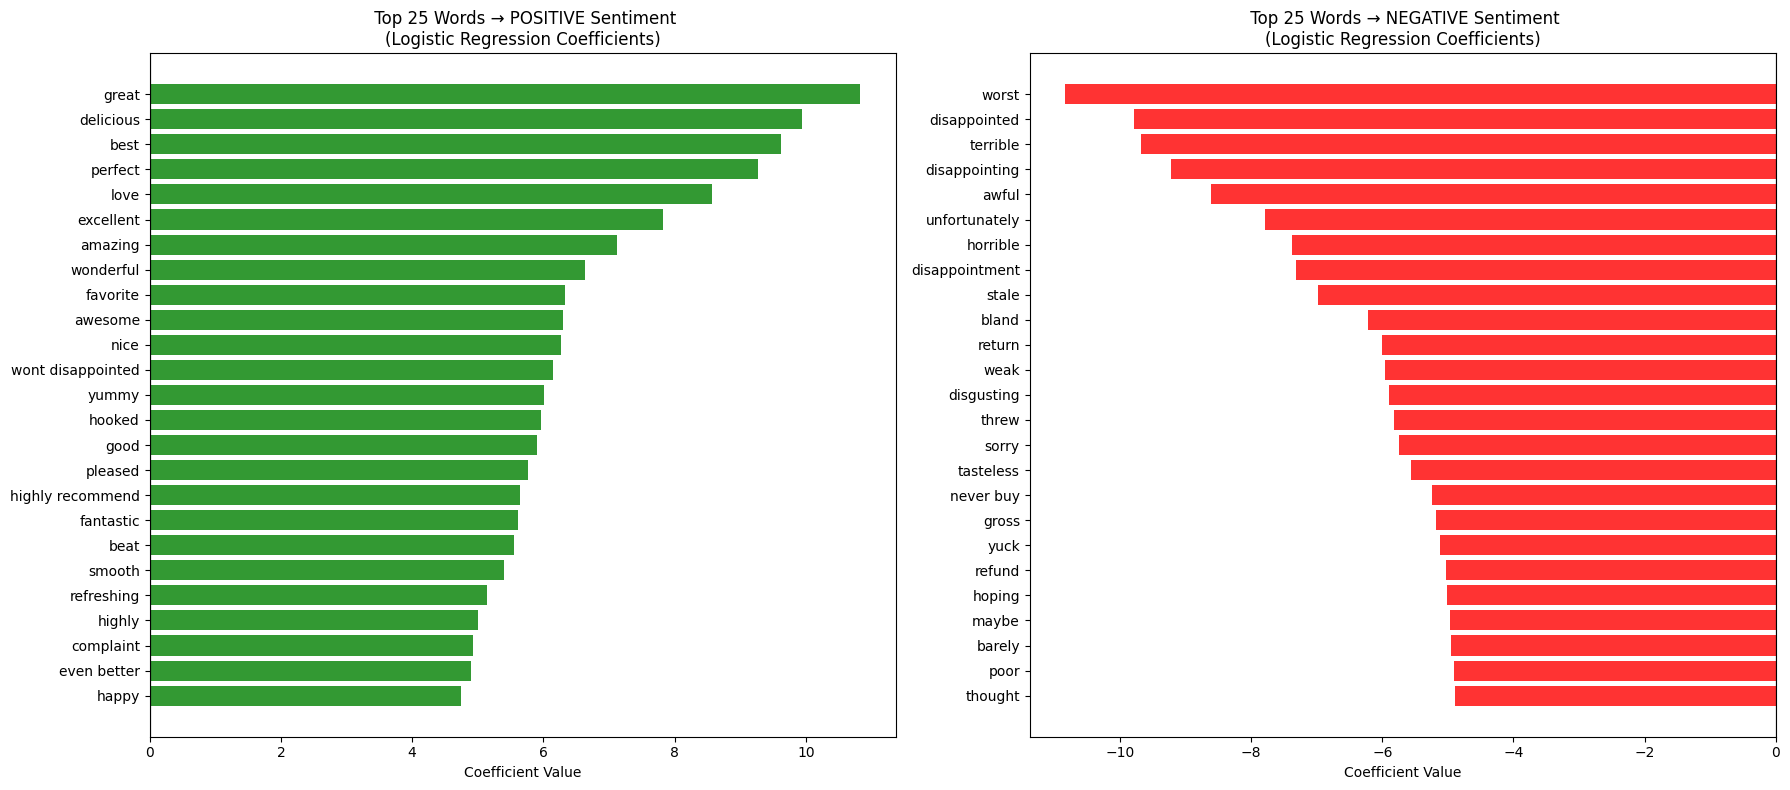


Review  : This product is absolutely amazing! Best purchase ever.
Cleaned : product absolutely amazing best purchase ever
Result  :  POSITIVE
Confidence → Positive: 99.82% | Negative: 0.18%

Review  : Terrible quality, waste of money. Never buying again.
Cleaned : terrible quality waste money never buying
Result  :  NEGATIVE
Confidence → Positive: 0.01% | Negative: 99.99%

Review  : It was okay, nothing special but not bad either.
Cleaned : okay nothing special bad either
Result  :  NEGATIVE
Confidence → Positive: 0.28% | Negative: 99.72%

Review  : The dog loved it but the packaging was horrible and leaking.
Cleaned : dog loved packaging horrible leaking
Result  :  NEGATIVE
Confidence → Positive: 1.56% | Negative: 98.44%


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get the best model — LR + TF-IDF
lr_model = results['Logistic Regression + TF-IDF']['model']
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients  = lr_model.coef_[0]

# ---- Top positive & negative words ----
top_n = 25
top_pos_idx = np.argsort(coefficients)[-top_n:][::-1]
top_neg_idx = np.argsort(coefficients)[:top_n]

top_pos_words  = feature_names[top_pos_idx]
top_pos_scores = coefficients[top_pos_idx]

top_neg_words  = feature_names[top_neg_idx]
top_neg_scores = coefficients[top_neg_idx]

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Positive drivers
axes[0].barh(top_pos_words[::-1], top_pos_scores[::-1], color='green', alpha=0.8)
axes[0].set_title(' Top 25 Words → POSITIVE Sentiment\n(Logistic Regression Coefficients)', fontsize=12)
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Negative drivers
axes[1].barh(top_neg_words[::-1], top_neg_scores[::-1], color='red', alpha=0.8)
axes[1].set_title(' Top 25 Words → NEGATIVE Sentiment\n(Logistic Regression Coefficients)', fontsize=12)
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ---- Live Prediction Function ----
def predict_sentiment(review_text):
    cleaned = full_clean(review_text)
    vec     = tfidf_vectorizer.transform([cleaned])
    pred    = lr_model.predict(vec)[0]
    proba   = lr_model.predict_proba(vec)[0]
    label   = " POSITIVE" if pred == 1 else " NEGATIVE"
    print(f"\nReview  : {review_text}")
    print(f"Cleaned : {cleaned}")
    print(f"Result  : {label}")
    print(f"Confidence → Positive: {proba[1]:.2%} | Negative: {proba[0]:.2%}")

# ---- Test on custom reviews ----
predict_sentiment("This product is absolutely amazing! Best purchase ever.")
predict_sentiment("Terrible quality, waste of money. Never buying again.")
predict_sentiment("It was okay, nothing special but not bad either.")
predict_sentiment("The dog loved it but the packaging was horrible and leaking.")

##  Step 8: Beyond TF-IDF — Word Embeddings with Word2Vec

TF-IDF treats every word independently — it has no idea that:
- "good" and "great" are similar
- "not good" and "bad" mean the same thing
- Word ORDER and CONTEXT don't exist in TF-IDF

Word2Vec solves this by learning dense vector representations
where similar words cluster together in vector space.

Key concepts:
- Each word → a vector of 100-300 numbers
- "king" - "man" + "woman" ≈ "queen"  (famous example!)
- We average word vectors to represent a whole review
- Then feed into same ML models

In [9]:
from gensim.models import Word2Vec
import numpy as np

# ---- Prepare tokenized sentences ----
print(" Tokenizing for Word2Vec...")
tokenized = df_balanced['cleaned_text'].apply(lambda x: str(x).split())
print(f"✅Total sentences: {len(tokenized):,}")
print(f"Sample tokens: {tokenized.iloc[0]}")

# ---- Train Word2Vec ----
print("\n Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,   # each word = 100-dim vector
    window=5,          # context window size
    min_count=5,       # ignore words appearing < 5 times
    workers=4,         # parallel threads
    epochs=5,
    sg=1               # Skip-gram (better for rare words)
)
print(f" Vocabulary size: {len(w2v_model.wv):,} words")

# ---- Explore the embedding space ----
print("\n===  SEMANTIC SIMILARITY ===")
print("\nWords similar to 'delicious':")
for word, score in w2v_model.wv.most_similar('delicious', topn=8):
    print(f"  {word:<20} similarity: {score:.4f}")

print("\nWords similar to 'terrible':")
for word, score in w2v_model.wv.most_similar('terrible', topn=8):
    print(f"  {word:<20} similarity: {score:.4f}")

print("\nWords similar to 'dog':")
for word, score in w2v_model.wv.most_similar('dog', topn=8):
    print(f"  {word:<20} similarity: {score:.4f}")

# ---- Famous vector arithmetic ----
print("\n===  VECTOR ARITHMETIC ===")
# good - great + terrible ≈ ?
result = w2v_model.wv.most_similar(
    positive=['terrible', 'good'], 
    negative=['great'], topn=5
)
print("'terrible' + 'good' - 'great' ≈")
for word, score in result:
    print(f"  {word:<20} {score:.4f}")

# ---- Convert reviews to vectors (mean pooling) ----
def review_to_vec(tokens, model, vec_size=100):
    """Average all word vectors in a review"""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(vec_size)
    return np.mean(vecs, axis=0)

print("\n Converting reviews to W2V vectors...")
X_train_tok = tokenized.iloc[X_train.index - X_train.index.min() 
                              if hasattr(X_train.index, 'min') else X_train.index]

# Safer approach using index alignment
train_idx = X_train.index
test_idx  = X_test.index

X_train_w2v = np.array([review_to_vec(tokenized[i], w2v_model) for i in train_idx])
X_test_w2v  = np.array([review_to_vec(tokenized[i], w2v_model) for i in test_idx])

print(f" Train W2V matrix: {X_train_w2v.shape}")
print(f" Test  W2V matrix: {X_test_w2v.shape}")

# ---- Train LR on W2V ----
print("\n Training Logistic Regression on Word2Vec vectors...")
lr_w2v = LogisticRegression(max_iter=1000, C=1.0)
lr_w2v.fit(X_train_w2v, y_train)
preds_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, preds_w2v)

print(f"\n{'='*45}")
print(f" Logistic Regression + Word2Vec")
print(f"{'='*45}")
print(f"Accuracy: {acc_w2v:.4f}")
print(classification_report(y_test, preds_w2v,
      target_names=['Negative', 'Positive']))

# ---- Final comparison ----
print("\n===  FINAL MODEL COMPARISON ===")
all_results = {
    'NB + BOW':          results['Naive Bayes + BOW']['accuracy'],
    'NB + TF-IDF':       results['Naive Bayes + TF-IDF']['accuracy'],
    'LR + BOW':          results['Logistic Regression + BOW']['accuracy'],
    'LR + TF-IDF':       results['Logistic Regression + TF-IDF']['accuracy'],
    'LR + Word2Vec':     acc_w2v
}
for model, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 50)
    print(f"{model:<25} {acc:.4f}  {bar}")

 Tokenizing for Word2Vec...
✅Total sentences: 164,074
Sample tokens: ['abc', 'hair', 'read', 'ton', 'material', 'product', 'best', 'hair', 'type', 'thought', 'best', 'get', 'away', 'petroleum', 'mineral', 'oil', 'two', 'main', 'ingredient', 'intense', 'scalp', 'nourishing', 'balm', 'however', 'gotta', 'go', 'know', 'read', 'stuff', 'work', 'totally', 'coat', 'seal', 'moisture', 'porous', 'dry', 'quickly', 'hair', 'light', 'little', 'go', 'long', 'way', 'growing', 'everybody', 'long', 'flowing', 'hair', 'mama', 'greased', 'scalp', 'twice', 'week', 'wore', 'protective', 'style', 'mama', 'grease', 'scalp', 'stuff', 'minus', 'shea', 'butter', 'im', 'going', 'back', 'old', 'school', 'way', 'new', 'school', 'twist']

 Training Word2Vec model...
 Vocabulary size: 23,934 words

===  SEMANTIC SIMILARITY ===

Words similar to 'delicious':
  yummy                similarity: 0.8860
  tasty                similarity: 0.8099
  delicous             similarity: 0.7799
  fantastic            similarity

IndexError: positional indexers are out-of-bounds

In [10]:
# ---- Fix: reset index for safe alignment ----
df_balanced_reset = df_balanced.reset_index(drop=True)
tokenized_reset   = df_balanced_reset['cleaned_text'].apply(lambda x: str(x).split())

# Redo train/test split with reset index
X2 = df_balanced_reset['cleaned_text']
y2 = df_balanced_reset['sentiment']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Convert to W2V vectors using positional index
print("⏳ Converting reviews to W2V vectors...")
X_train_w2v = np.array([
    review_to_vec(tokenized_reset[i], w2v_model) 
    for i in X_train2.index
])
X_test_w2v = np.array([
    review_to_vec(tokenized_reset[i], w2v_model) 
    for i in X_test2.index
])

print(f"✅ Train W2V matrix: {X_train_w2v.shape}")
print(f"✅ Test  W2V matrix: {X_test_w2v.shape}")

# ---- Train LR on W2V ----
print("\n⏳ Training Logistic Regression on Word2Vec vectors...")
lr_w2v = LogisticRegression(max_iter=1000, C=1.0)
lr_w2v.fit(X_train_w2v, y_train2)
preds_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v   = accuracy_score(y_test2, preds_w2v)

print(f"\n{'='*45}")
print(f"📌 Logistic Regression + Word2Vec")
print(f"{'='*45}")
print(f"Accuracy: {acc_w2v:.4f}")
print(classification_report(y_test2, preds_w2v,
      target_names=['Negative', 'Positive']))

# ---- Final Leaderboard ----
print("\n=== 🏆 FINAL MODEL COMPARISON ===")
all_results = {
    'NB + BOW':      results['Naive Bayes + BOW']['accuracy'],
    'NB + TF-IDF':   results['Naive Bayes + TF-IDF']['accuracy'],
    'LR + BOW':      results['Logistic Regression + BOW']['accuracy'],
    'LR + TF-IDF':   results['Logistic Regression + TF-IDF']['accuracy'],
    'LR + Word2Vec': acc_w2v
}
for model, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 50)
    print(f"{model:<25} {acc:.4f}  {bar}")

⏳ Converting reviews to W2V vectors...
✅ Train W2V matrix: (131259, 100)
✅ Test  W2V matrix: (32815, 100)

⏳ Training Logistic Regression on Word2Vec vectors...

📌 Logistic Regression + Word2Vec
Accuracy: 0.8632
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     16408
    Positive       0.86      0.86      0.86     16407

    accuracy                           0.86     32815
   macro avg       0.86      0.86      0.86     32815
weighted avg       0.86      0.86      0.86     32815


=== 🏆 FINAL MODEL COMPARISON ===
LR + TF-IDF               0.9046  █████████████████████████████████████████████
LR + BOW                  0.8954  ████████████████████████████████████████████
NB + TF-IDF               0.8799  ███████████████████████████████████████████
LR + Word2Vec             0.8632  ███████████████████████████████████████████
NB + BOW                  0.8581  ██████████████████████████████████████████


##  Step 9: t-SNE — Visualizing Word Embeddings in 2D

Word2Vec creates 100-dimensional vectors — impossible to visualize directly.
t-SNE (t-Distributed Stochastic Neighbor Embedding) compresses 
100 dimensions → 2 dimensions while preserving neighborhood structure.

If Word2Vec learned well, we should see:
- Positive words clustering together (green)
- Negative words clustering together (red)
- Food/product words in their own region

Visualizing 60 words...


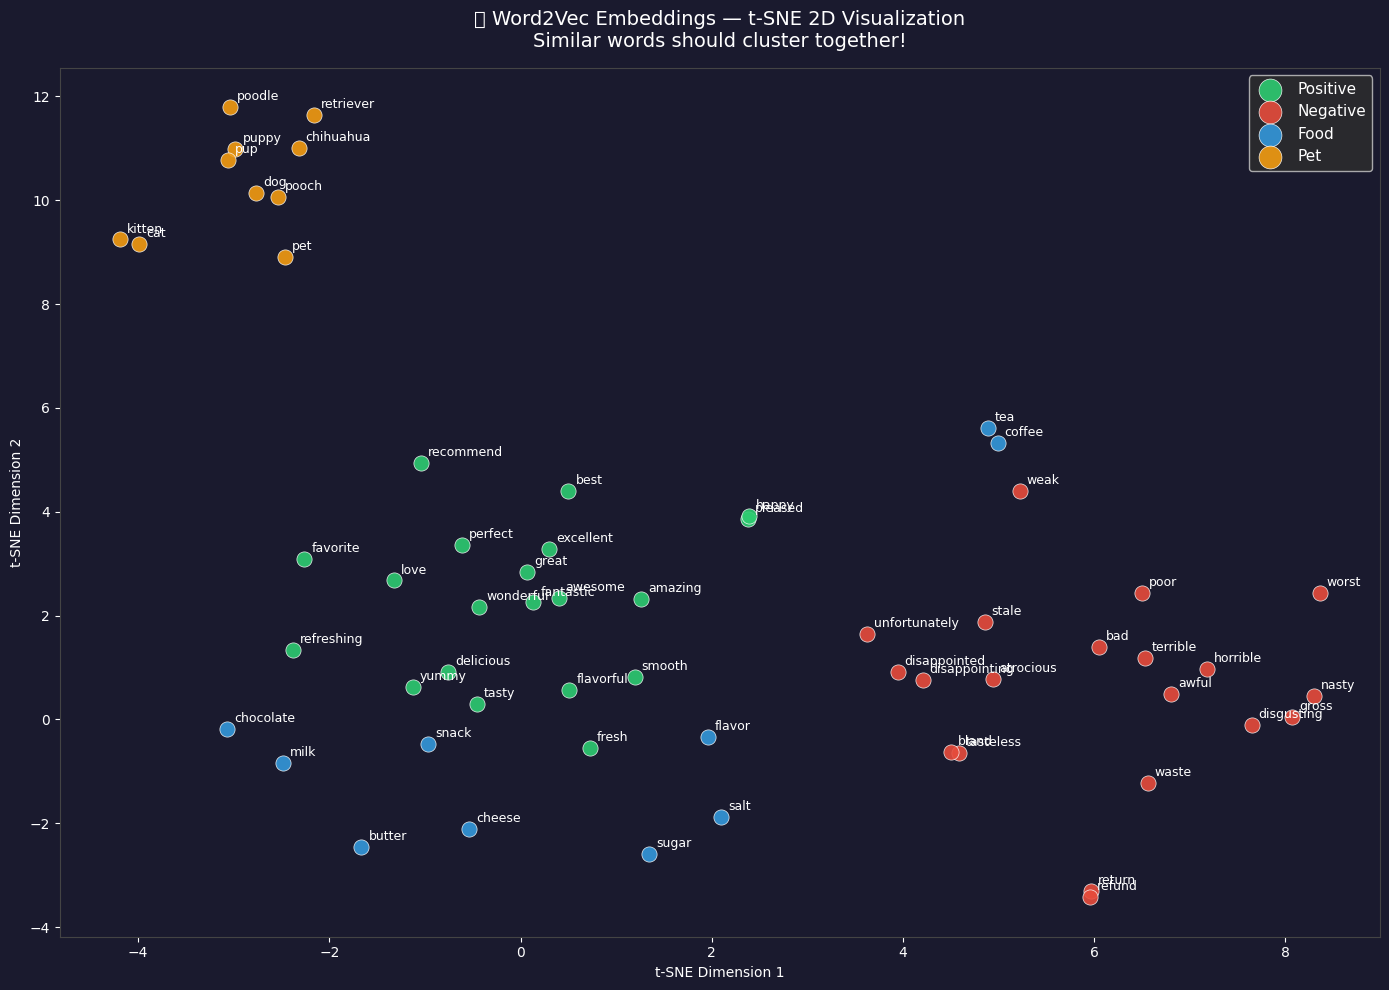


✅ If positive (green) and negative (red) words form
   separate clusters — Word2Vec has learned sentiment geometry!


In [11]:
from sklearn.manifold import TSNE

# ---- Select words to visualize ----
positive_words = [
    'delicious', 'yummy', 'tasty', 'great', 'love', 'excellent',
    'perfect', 'wonderful', 'amazing', 'fantastic', 'fresh',
    'recommend', 'best', 'favorite', 'awesome', 'pleased',
    'happy', 'smooth', 'refreshing', 'flavorful'
]

negative_words = [
    'terrible', 'horrible', 'awful', 'disgusting', 'worst',
    'disappointed', 'bad', 'nasty', 'poor', 'tasteless',
    'bland', 'stale', 'gross', 'waste', 'return',
    'refund', 'unfortunately', 'disappointing', 'atrocious', 'weak'
]

food_words = [
    'coffee', 'tea', 'chocolate', 'sugar', 'salt',
    'butter', 'cheese', 'milk', 'flavor', 'snack'
]

pet_words = [
    'dog', 'cat', 'puppy', 'kitten', 'pup',
    'poodle', 'retriever', 'chihuahua', 'pooch', 'pet'
]

# ---- Collect words that exist in vocabulary ----
all_words  = positive_words + negative_words + food_words + pet_words
labels     = (['positive'] * len(positive_words) + 
               ['negative'] * len(negative_words) +
               ['food']     * len(food_words) +
               ['pet']      * len(pet_words))

# Filter to vocab
valid = [(w, l) for w, l in zip(all_words, labels) if w in w2v_model.wv]
words_valid, labels_valid = zip(*valid)

# Get vectors
word_vectors = np.array([w2v_model.wv[w] for w in words_valid])
print(f"Visualizing {len(words_valid)} words...")

# ---- Run t-SNE ----
tsne = TSNE(n_components=2, random_state=42, 
            perplexity=15, n_iter=1000)
vectors_2d = tsne.fit_transform(word_vectors)

# ---- Plot ----
color_map = {
    'positive': '#2ecc71',
    'negative': '#e74c3c', 
    'food':     '#3498db',
    'pet':      '#f39c12'
}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

for category in ['positive', 'negative', 'food', 'pet']:
    mask = [l == category for l in labels_valid]
    x = vectors_2d[mask, 0]
    y = vectors_2d[mask, 1]
    ax.scatter(x, y, 
               c=color_map[category], 
               label=category.capitalize(),
               s=120, alpha=0.9, edgecolors='white', linewidth=0.5)
    # Add word labels
    for i, (xi, yi) in enumerate(zip(x, y)):
        word = [w for w, l in zip(words_valid, labels_valid) if l == category][i]
        ax.annotate(word, (xi, yi),
                   fontsize=9, color='white',
                   xytext=(5, 5), textcoords='offset points')

ax.set_title('🗺️ Word2Vec Embeddings — t-SNE 2D Visualization\n'
             'Similar words should cluster together!', 
             fontsize=14, color='white', pad=15)
ax.legend(fontsize=11, facecolor='#2d2d2d', 
          labelcolor='white', markerscale=1.5)
ax.set_xlabel('t-SNE Dimension 1', color='white')
ax.set_ylabel('t-SNE Dimension 2', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

print("\n✅ If positive (green) and negative (red) words form")
print("   separate clusters — Word2Vec has learned sentiment geometry!")

##  Step 10: Final Summary & What We Learned

Complete NLP Pipeline from raw text → production-ready model.


╔══════════════════════════════════════════════════════════════╗
║            NLP NOTEBOOK — COMPLETE SUMMARY                 ║
╚══════════════════════════════════════════════════════════════╝

 DATASET
   • Amazon Fine Food Reviews
   • 568,454 reviews | 10 columns
   • Task: Predict Positive vs Negative sentiment

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 EDA FINDINGS
   • Heavily imbalanced: 363K positive vs 52K negative
   • Negative reviews are longer (90 words) than positive (74)
   • HTML tags present in raw text (<br /> etc.)
   • Key positive signal words: great, delicious, recommend
   • Key negative signal words: disappointed, terrible, waste

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 PREPROCESSING PIPELINE
    Lowercasing
    HTML tag removal (re.sub)
    Special character removal
    Stopword removal (NLTK)
    Lemmatization (WordNetLemmatizer)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  FEATURE ENGINEERING
  

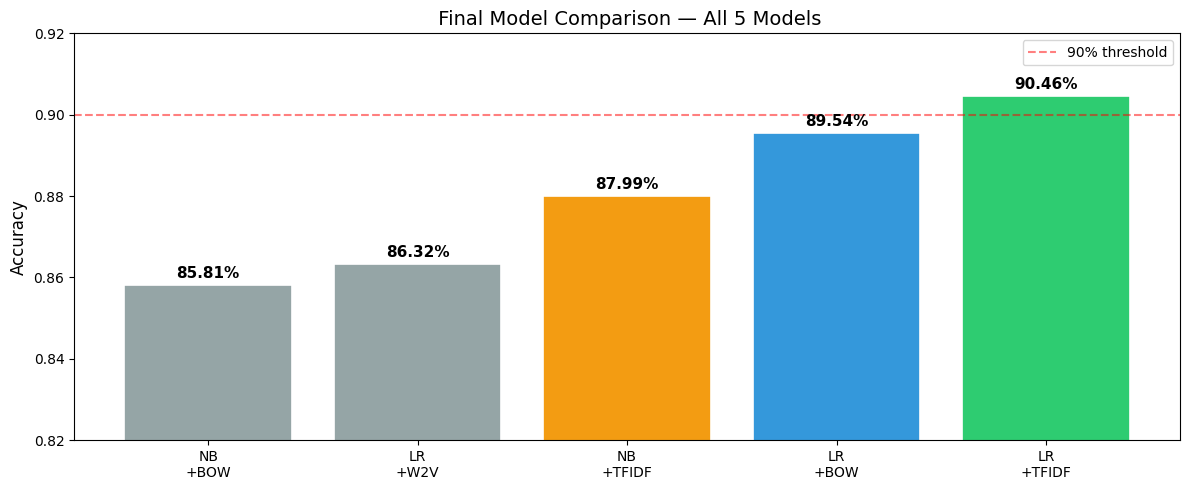

In [13]:
print("""
╔══════════════════════════════════════════════════════════════╗
║            NLP NOTEBOOK — COMPLETE SUMMARY                 ║
╚══════════════════════════════════════════════════════════════╝

 DATASET
   • Amazon Fine Food Reviews
   • 568,454 reviews | 10 columns
   • Task: Predict Positive vs Negative sentiment

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 EDA FINDINGS
   • Heavily imbalanced: 363K positive vs 52K negative
   • Negative reviews are longer (90 words) than positive (74)
   • HTML tags present in raw text (<br /> etc.)
   • Key positive signal words: great, delicious, recommend
   • Key negative signal words: disappointed, terrible, waste

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 PREPROCESSING PIPELINE
    Lowercasing
    HTML tag removal (re.sub)
    Special character removal
    Stopword removal (NLTK)
    Lemmatization (WordNetLemmatizer)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  FEATURE ENGINEERING
   • Bag of Words  → 10,000 features (word counts)
   • TF-IDF        → 10,000 features + bigrams (smarter weights)
   • Word2Vec      → 100-dim dense vectors (semantic meaning)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 MODEL RESULTS
   LR  + TF-IDF   → 90.46%  WINNER
   LR  + BOW      → 89.54%
   NB  + TF-IDF   → 87.99%
   LR  + Word2Vec → 86.32%
   NB  + BOW      → 85.81%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 KEY LESSONS
   1. TF-IDF > BOW because rare important words get boosted
   2. Bigrams capture phrases: "never buy", "highly recommend"
   3. LR > NaiveBayes because it learns word weights
   4. Word2Vec mean-pooling loses context → needs deep learning
   5. Class imbalance MUST be handled before modeling
   6. Negative reviews are longer — people explain complaints more

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 WHAT'S NEXT — LEVEL UP TO:
   • LSTM / GRU          → Word order matters now
   • BERT (HuggingFace)  → Contextual embeddings, 94%+ accuracy
   • Aspect-based SA     → "packaging bad but taste great"
   • Streamlit App       → Deploy your model live!

╔══════════════════════════════════════════════════════════════╗
║  Ywe built a complete NLP pipeline from scratch!           ║
╚══════════════════════════════════════════════════════════════╝
""")

# ---- Final bar chart of all models ----
models = ['NB\n+BOW', 'LR\n+W2V', 'NB\n+TFIDF', 'LR\n+BOW', 'LR\n+TFIDF']
scores = [0.8581,    0.8632,     0.8799,       0.8954,    0.9046]
colors = ['#95a5a6', '#95a5a6',  '#f39c12',    '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(models, scores, color=colors, edgecolor='white', linewidth=1.2)
ax.set_ylim(0.82, 0.92)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(' Final Model Comparison — All 5 Models', fontsize=14)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.001,
            f'{score:.2%}', ha='center', va='bottom', 
            fontweight='bold', fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()